In [2]:
import pandas as pd
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, 
    classification_report,
    RocCurveDisplay)

In [3]:
df = pd.read_csv('deliriumwatch_clean_V5.csv')

In [4]:
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("NaN after fix:", df.isnull().sum().sum())


NaN after fix: 0


In [5]:
X = df.drop(columns=['delirium_label'])
y = df['delirium_label']

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features shape: (25843, 27)
Target distribution:
delirium_label
0    14028
1    11815
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

AUROC: 0.7655

Classification Report:
              precision    recall  f1-score   support

 No Delirium       0.72      0.72      0.72      2806
    Delirium       0.67      0.68      0.67      2363

    accuracy                           0.70      5169
   macro avg       0.70      0.70      0.70      5169
weighted avg       0.70      0.70      0.70      5169



C:\Users\basav\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


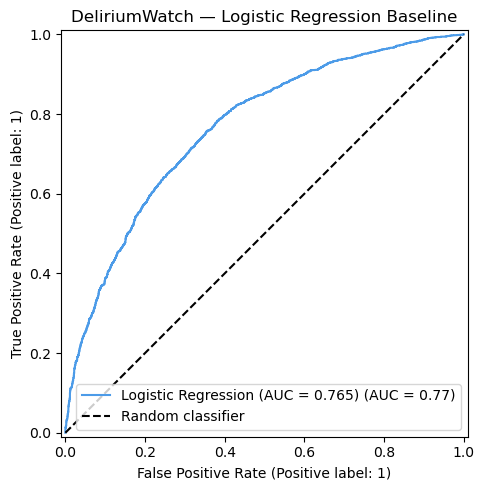

In [8]:
# Logistic Regression baseline
lr = LogisticRegression(
    class_weight='balanced',  # handles 64/36 imbalance
    max_iter=1000,            # enough iterations to converge
    random_state=42
)

lr.fit(X_train_scaled, y_train)

# Predict probabilities (not just 0/1)
# AUROC needs probabilities, not hard predictions
y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
y_pred = lr.predict(X_test_scaled)

# Metrics
auroc = roc_auc_score(y_test, y_pred_proba)
print(f"AUROC: {auroc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['No Delirium', 'Delirium']))

# ROC Curve
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test, y_pred_proba,
    name=f"Logistic Regression (AUC = {auroc:.3f})",
    ax=ax, color='#4C9BE8'
)
ax.plot([0,1],[0,1],'k--', label='Random classifier')
ax.set_title('DeliriumWatch — Logistic Regression Baseline')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
X_train_no_nid = X_train.drop(columns=['nid_score'])
X_test_no_nid = X_test.drop(columns=['nid_score'])

xgb_no_nid = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=14028/11815,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_no_nid.fit(X_train_no_nid, y_train)
y_pred_no_nid = xgb_no_nid.predict_proba(
    X_test_no_nid
)[:, 1]

auroc_no_nid = roc_auc_score(y_test, y_pred_no_nid)


print(f"XGBoost WITHOUT nid_score: {auroc_no_nid:.4f}")

XGBoost WITHOUT nid_score: 0.8123


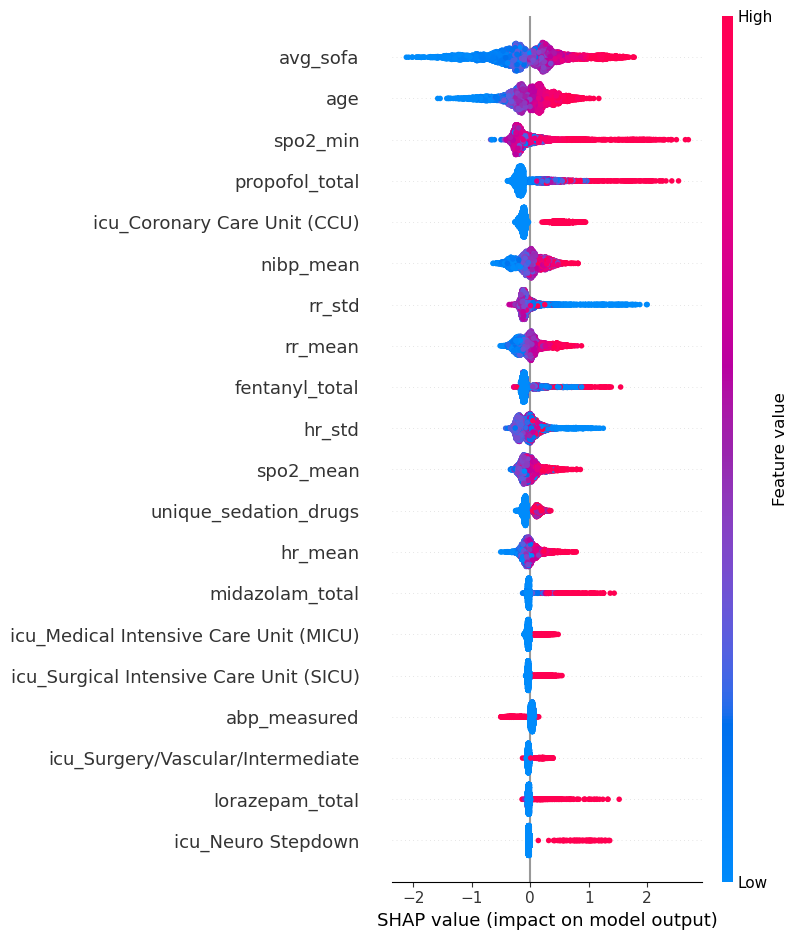

In [11]:
import shap
explainer = shap.TreeExplainer(xgb_no_nid)
shap_values = explainer.shap_values(X_test_no_nid)
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test_no_nid,
    feature_names=X.columns.tolist(),
    max_display=20,
    show=True
)

In [12]:
import pickle

# save model to file
with open('xgb_no_nid.pkl', 'wb') as f:
    pickle.dump(xgb_no_nid, f)